In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

In [48]:
# Единый стиль для всех графиков
sb.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [129]:
df_goals = pd.read_excel('Тестовое задание_аналитик_2025.xlsx', sheet_name="данные", engine='openpyxl', skiprows=2, usecols=range(12, 20), index_col=None)

In [130]:
df_goals = df_goals.dropna()
first_column_name = df_goals.columns[0]
df_goals = df_goals.set_index(first_column_name)
df_goals = df_goals.T.copy()
df_goals.columns.name = None
df_goals.reset_index(inplace=True)
df_goals.rename(columns={'index': 'Месяц'}, inplace=True)
df_goals

,Месяц,"Конверсия, %","UPT, шт."
0,Март,0.113321,1.645528
1,Апрель,0.149218,1.688931
2,Май,0.167771,1.969249
3,Июнь,0.212170,1.712976
4,Июль,0.200368,1.672998
5,Август,0.131015,1.920391
6,Итого:,0.164576,1.762192


In [4]:
df_raw = pd.read_excel('Тестовое задание_аналитик_2025.xlsx', sheet_name="данные", engine='openpyxl', skiprows=2, usecols=range(1, 10))

In [5]:
df_raw

,ID магазина,Категория магазина,ФО,Год,Месяц,День,Посетители,Покупатели,Продано шт
0,101,C,Москва и МО,2024,Март,2024-03-01,302,23,38
1,101,C,Москва и МО,2024,Март,2024-03-02,441,50,75
2,101,C,Москва и МО,2024,Март,2024-03-03,544,74,113
3,101,C,Москва и МО,2024,Март,2024-03-04,340,25,42
4,101,C,Москва и МО,2024,Март,2024-03-05,296,24,34
...,...,...,...,...,...,...,...,...,...
111253,997,Outlet,Москва и МО,2025,Апрель,2025-04-13,497,125,327
111254,997,Outlet,Москва и МО,2025,Апрель,2025-04-14,226,62,120
111255,997,Outlet,Москва и МО,2025,Апрель,2025-04-15,247,62,124
111256,997,Outlet,Москва и МО,2025,Апрель,2025-04-16,260,72,157


In [6]:
df_raw["День"] = pd.to_datetime(df_raw["День"])

month_order = {
    "Март": 3,
    "Апрель": 4,
    "Май": 5,
    "Июнь": 6,
    "Июль": 7,
    "Август": 8
}

df_raw["Номер месяца"] = df_raw["Месяц"].map(month_order)
df = df_raw

In [7]:
print("\nПропуски:")
print(df.isna().sum())


Пропуски:
ID магазина           0
Категория магазина    0
ФО                    0
Год                   0
Месяц                 0
День                  0
Посетители            0
Покупатели            0
Продано шт            0
Номер месяца          0
dtype: int64


In [8]:
print("\nДубликаты:")
print(df.duplicated().sum())


Дубликаты:
0


In [9]:
key = ["ID магазина", "День"]

duplicates = (
    df.groupby(key)
      .size()
      .reset_index(name="count")
      .query("count > 1")
)

print("\nДубликаты 'ID магазина', 'День':")
print(duplicates)


Дубликаты 'ID магазина', 'День':
Empty DataFrame
Columns: [ID магазина, День, count]
Index: []


In [10]:
print("\nПосетители <= 0:")
print(df[df["Посетители"] <= 0].shape[0])

print("\nПокупатели < 0:")
print(df[df["Покупатели"] < 0].shape[0])

print("\nПокупатели > посетителей:")
print((df["Покупатели"] > df["Посетители"]).sum())

print("\nПродажи < 0:")
print((df["Продано шт"] < 0).sum())

print("\nПродажи < покупателей:")
print((df["Продано шт"] < df["Покупатели"]).sum())


Посетители <= 0:
23

Покупатели < 0:
0

Покупатели > посетителей:
33

Продажи < 0:
3

Продажи < покупателей:
209


In [11]:
# Рассчитываем UPT и Конверсию
df["UPT"] = np.where(
    df["Покупатели"] > 0,
    df["Продано шт"] / df["Покупатели"],
    np.nan
)

df["Конверсия"] = np.where(
    df["Посетители"] > 0,
    df["Покупатели"] / df["Посетители"],
    np.nan
)

In [12]:
monthly = (
    df.groupby(
        [
            "ID магазина",
            "Категория магазина",
            "ФО",
            "Год",
            "Месяц",
            "Номер месяца"
        ],
        as_index=False
    ).agg(
        Посетители=("Посетители", "sum"),
        Покупатели=("Покупатели", "sum"),
        Продано_шт=("Продано шт", "sum"),
        Дней_в_данных=("День", "nunique")
    )
)
monthly["Конверсия"] = (
    monthly["Покупатели"] /
    monthly["Посетители"]
)

monthly["UPT"] = (
    monthly["Продано_шт"] /
    monthly["Покупатели"]
)
monthly = monthly.sort_values(
    ["Год", "Номер месяца", "ID магазина"]
)

In [13]:
monthly

,ID магазина,Категория магазина,ФО,Год,Месяц,Номер месяца,Посетители,Покупатели,Продано_шт,Дней_в_данных,Конверсия,UPT
5,2,E,Приволжский округ,2024,Март,3,27137,2300,3191,31,0.084755,1.387391
13,3,B,Москва и МО,2024,Март,3,6448,614,966,31,0.095223,1.573290
21,4,A,Москва и МО,2024,Март,3,8720,695,1036,31,0.079702,1.490647
29,29,C,Санкт Петербург и Ленинградская область,2024,Март,3,21759,2494,3689,31,0.114619,1.479150
37,35,B,Центральный округ,2024,Март,3,18214,1529,2111,31,0.083946,1.380641
...,...,...,...,...,...,...,...,...,...,...,...,...
3853,3207,C,Санкт Петербург и Ленинградская область,2025,Апрель,4,15033,1122,1661,17,0.074636,1.480392
3855,3212,B,Приволжский округ,2025,Апрель,4,4368,276,442,17,0.063187,1.601449
3857,3230,Outlet,Москва и МО,2025,Апрель,4,13339,3033,6191,17,0.227378,2.041213
3859,3295,C,Москва и МО,2025,Апрель,4,3748,598,903,17,0.159552,1.510033


# Количество магазинов

In [14]:
print("Количество магазинов:", monthly["ID магазина"].nunique())

print(
    "Период:",
    monthly[["Год", "Номер месяца"]]
    .drop_duplicates()
    .sort_values(["Год", "Номер месяца"])
)

Количество магазинов: 502
Период:     Год  Номер месяца
5  2024             3
1  2024             4
4  2024             5
3  2024             6
2  2024             7
0  2024             8
7  2025             3
6  2025             4


# Количество наблюдений

In [15]:
print(
    monthly
    .groupby("Год")
    .agg(
        stores=("ID магазина", "nunique"),
        observations=("ID магазина", "size")
    )
)

      stores  observations
Год                       
2024     495          2880
2025     492           983


# Динамика компании по месяцам все магазины

In [16]:
company_monthly = (
    monthly
    .groupby(
        ["Год", "Месяц", "Номер месяца"],
        as_index=False
    )
    .agg(
        Магазинов=("ID магазина", "nunique"),
        Посетители=("Посетители", "sum"),
        Покупатели=("Покупатели", "sum"),
        Продано_шт=("Продано_шт", "sum")
    )
)

company_monthly["Конверсия"] = (
    company_monthly["Покупатели"] /
    company_monthly["Посетители"]
)

company_monthly["UPT"] = (
    company_monthly["Продано_шт"] /
    company_monthly["Покупатели"]
)

company_monthly = company_monthly.sort_values(
    ["Год", "Номер месяца"]
)

company_monthly

,Год,Месяц,Номер месяца,Магазинов,Посетители,Покупатели,Продано_шт,Конверсия,UPT
5,2024,Март,3,475,7315495,708548,1051882,0.096856,1.484560
1,2024,Апрель,4,475,6764021,862659,1430009,0.127536,1.657676
4,2024,Май,5,478,7085359,1016000,1767051,0.143394,1.739223
3,2024,Июнь,6,479,9107434,1651559,2983505,0.181342,1.806478
2,2024,Июль,7,482,7958183,1362875,2343291,0.171255,1.719373
0,2024,Август,8,491,7809032,874445,1419223,0.111979,1.622999
7,2025,Март,3,492,6710796,714462,1115340,0.106465,1.561091
6,2025,Апрель,4,491,3036929,351109,568517,0.115613,1.619204


# Распределение по магазинам

In [17]:
store_stats = (
    monthly
    .groupby(
        [
            "ID магазина",
            "Категория магазина",
            "ФО"
        ],
        as_index=False
    )
    .agg(
        Средняя_конверсия=("Конверсия", "mean"),
        Медианная_конверсия=("Конверсия", "median"),
        Средний_UPT=("UPT", "mean"),
        Медианный_UPT=("UPT", "median"),
        Средний_трафик=("Посетители", "mean"),
        Месяцев_наблюдений=("Месяц", "count")
    )
)
store_stats.describe()

,ID магазина,Средняя_конверсия,Медианная_конверсия,Средний_UPT,Медианный_UPT,Средний_трафик,Месяцев_наблюдений
count,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000,502.000000
mean,1521.884462,0.142530,0.135120,1.637890,1.636863,14425.293704,7.695219
std,1102.726454,0.046164,0.047476,0.127718,0.128833,7436.627465,1.141110
min,2.000000,0.048010,0.046759,1.325705,1.340293,3011.250000,1.000000
25%,392.000000,0.109990,0.100574,1.543473,1.539551,9446.281250,8.000000
50%,1525.000000,0.134454,0.126726,1.628458,1.625691,13084.562500,8.000000
75%,2604.000000,0.169122,0.160424,1.712671,1.716282,17735.656250,8.000000
max,3300.000000,0.303895,0.295274,2.079368,2.107119,65856.750000,8.000000


Дополнительно посмотрим квантили

In [18]:
store_stats[
    [
        "Средняя_конверсия",
        "Медианная_конверсия",
        "Средний_UPT",
        "Медианный_UPT"
    ]
].quantile(
    [0.05, 0.25, 0.50, 0.75, 0.95]
)

,Средняя_конверсия,Медианная_конверсия,Средний_UPT,Медианный_UPT
0.05,0.083093,0.074182,1.455554,1.452245
0.25,0.109990,0.100574,1.543473,1.539551
0.50,0.134454,0.126726,1.628458,1.625691
0.75,0.169122,0.160424,1.712671,1.716282
0.95,0.226295,0.223107,1.868417,1.880777


ТОП-10 магазинов с самой высокой конверсией

In [19]:
print(
    store_stats
    .sort_values("Средняя_конверсия")
    [["ID магазина", "Категория магазина", "ФО", "Средняя_конверсия", "Средний_UPT"]]
    .head(10)
)

     ID магазина Категория магазина                       ФО  \
494         3199                  C        Приволжский округ   
496         3206                  B              Москва и МО   
115          325                  D              Южный округ   
56           171                  C        Центральный округ   
395         2695                  D        Приволжский округ   
203          976                  B        Приволжский округ   
473         3118                  B          Сибирский округ   
228         1281                  C  Северо-Кавказский округ   
242         1451                  B        Приволжский округ   
393         2677                  E          Уральский округ   

     Средняя_конверсия  Средний_UPT  
494           0.048010     1.476672  
496           0.049246     1.657640  
115           0.056402     1.433462  
56            0.057680     1.507113  
395           0.058192     1.425563  
203           0.059567     1.668834  
473           0.060998     1.

ТОП-10 магазинов с низкой конверсией

In [20]:
print(
    store_stats
    .sort_values("Средняя_конверсия", ascending=False)
    [["ID магазина", "Категория магазина", "ФО", "Средняя_конверсия", "Средний_UPT"]]
    .head(10)
)

     ID магазина Категория магазина                                       ФО  \
245         1475                  E                    Северо-Западный округ   
337         2242                  E                    Дальневосточный округ   
306         2042             Outlet                        Приволжский округ   
342         2330                  E                    Дальневосточный округ   
156          526                  B                    Дальневосточный округ   
286         1882                  D                          Сибирский округ   
181          678                  C                          Сибирский округ   
240         1431                  D                    Дальневосточный округ   
382         2633                  D  Санкт Петербург и Ленинградская область   
456         3063                  C                              Москва и МО   

     Средняя_конверсия  Средний_UPT  
245           0.303895     1.866060  
337           0.300381     2.077619  
306  

# По категориям магазина

In [21]:
category_monthly = (
    monthly
    .groupby(
        ["Год", "Месяц", "Номер месяца", "Категория магазина"],
        as_index=False
    )
    .agg(
        Магазинов=("ID магазина", "nunique"),
        Посетители=("Посетители", "sum"),
        Покупатели=("Покупатели", "sum"),
        Продано_шт=("Продано_шт", "sum")
    )
)

category_monthly["Конверсия"] = (
    category_monthly["Покупатели"] /
    category_monthly["Посетители"]
)

category_monthly["UPT"] = (
    category_monthly["Продано_шт"] /
    category_monthly["Покупатели"]
)
category_monthly

,Год,Месяц,Номер месяца,Категория магазина,Магазинов,Посетители,Покупатели,Продано_шт,Конверсия,UPT
0,2024,Август,8,A,9,97191,6782,9614,0.069780,1.417576
1,2024,Август,8,B,123,1599084,148880,230294,0.093103,1.546843
2,2024,Август,8,C,157,2376172,247202,390482,0.104034,1.579607
3,2024,Август,8,D,63,1054951,126582,207268,0.119989,1.637421
4,2024,Август,8,E,87,1800375,222934,377126,0.123826,1.691649
5,2024,Август,8,Outlet,46,742614,109454,184370,0.147390,1.684452
6,2024,Август,8,W,6,138645,12611,20069,0.090959,1.591388
7,2024,Апрель,4,A,9,88548,8887,13220,0.100364,1.487566
8,2024,Апрель,4,B,116,1362580,154266,246622,0.113216,1.598680
9,2024,Апрель,4,C,147,1958684,236773,386887,0.120884,1.634000


In [22]:
category_2024 = (
    category_monthly[
        category_monthly["Год"] == 2024
    ]
    .groupby("Категория магазина")
    .agg(
        Конверсия=("Конверсия", "mean"),
        UPT=("UPT", "mean"),
        Магазинов=("Магазинов", "mean")
    )
    .sort_values("Конверсия")
)

category_2024

,Конверсия,UPT,Магазинов
Категория магазина,,,
A,0.116844,1.505662,9.000000
B,0.123158,1.601338,117.833333
W,0.129082,1.673598,6.000000
C,0.131711,1.646007,151.333333
E,0.145221,1.725881,86.166667
D,0.149104,1.686443,62.500000
Outlet,0.165600,1.720074,47.166667


# По федеральным округам

In [ ]:
fo_monthly = (
    monthly
    .groupby(
        ["Год", "Месяц", "Номер месяца", "ФО"],
        as_index=False
    )
    .agg(
        Магазинов=("ID магазина", "nunique"),
        Посетители=("Посетители", "sum"),
        Покупатели=("Покупатели", "sum"),
        Продано_шт=("Продано_шт", "sum")
    )
)

fo_monthly["Конверсия"] = (
    fo_monthly["Покупатели"] /
    fo_monthly["Посетители"]
)

fo_monthly["UPT"] = (
    fo_monthly["Продано_шт"] /
    fo_monthly["Покупатели"]
)
display(fo_monthly)

,Год,Месяц,Номер месяца,ФО,Магазинов,Посетители,Покупатели,Продано_шт,Конверсия,UPT
0,2024,Август,8,Дальневосточный округ,25,401892,51248,93367,0.127517,1.821866
1,2024,Август,8,Москва и МО,97,1232123,147646,247924,0.119831,1.679179
2,2024,Август,8,Приволжский округ,105,1893442,184441,282794,0.097410,1.533249
3,2024,Август,8,Санкт Петербург и Ленинградская область,26,427877,55106,89031,0.128789,1.615632
4,2024,Август,8,Северо-Западный округ,31,523738,58853,91988,0.112371,1.563013
...,...,...,...,...,...,...,...,...,...,...
75,2025,Март,3,Северо-Кавказский округ,13,98872,11351,18429,0.114805,1.623557
76,2025,Март,3,Сибирский округ,44,641840,77196,120346,0.120273,1.558967
77,2025,Март,3,Уральский округ,55,892215,87313,136150,0.097861,1.559333
78,2025,Март,3,Центральный округ,57,744410,74219,111175,0.099702,1.497932


# Анализ стабильности магазинов

In [30]:
company_reference = (
    monthly
    .groupby(
        ["Год", "Месяц", "Номер месяца"],
        as_index=False
    )
    .agg(
        company_visitors=("Посетители", "sum"),
        company_buyers=("Покупатели", "sum"),
        company_units=("Продано_шт", "sum")
    )
)

company_reference["company_conversion"] = (
    company_reference["company_buyers"] /
    company_reference["company_visitors"]
)

company_reference["company_upt"] = (
    company_reference["company_units"] /
    company_reference["company_buyers"]
)

monthly = monthly.merge(
    company_reference[
        [
            "Год",
            "Месяц",
            "Номер месяца",
            "company_conversion",
            "company_upt"
        ]
    ],
    on=["Год", "Месяц", "Номер месяца"],
    how="left"
)

# _Index > 1 - магазин выше компании, _Index < 1 магазин ниже компании
monthly["Conversion_Index"] = (
    monthly["Конверсия"] /
    monthly["company_conversion"]
)

monthly["UPT_Index"] = (
    monthly["UPT"] /
    monthly["company_upt"]
)

In [33]:
store_2024 = (
    monthly[
        monthly["Год"] == 2024
    ]
    .groupby("ID магазина")
    .agg(
        Avg_Conversion_Index_2024=(
            "Conversion_Index",
            "mean"
        ),
        Avg_UPT_Index_2024=(
            "UPT_Index",
            "mean"
        )
    )
)
store_2024

,Avg_Conversion_Index_2024,Avg_UPT_Index_2024
ID магазина,,
2,0.985653,0.945338
3,1.128630,0.990164
4,0.939392,0.954071
29,1.187072,0.970441
35,0.921428,0.936035
...,...,...
3197,0.949232,1.206364
3199,0.417567,0.925737
3205,0.613004,0.985708


In [34]:
store_2025 = (
    monthly[
        monthly["Год"] == 2025
    ]
    .groupby("ID магазина")
    .agg(
        Avg_Conversion_Index_2025=(
            "Conversion_Index",
            "mean"
        ),
        Avg_UPT_Index_2025=(
            "UPT_Index",
            "mean"
        )
    )
)
store_2025

,Avg_Conversion_Index_2025,Avg_UPT_Index_2025
ID магазина,,
2,0.926612,0.913958
3,1.145883,1.044033
4,0.806616,0.928742
29,1.061196,0.939225
35,0.804119,0.900441
...,...,...
3207,0.646508,0.929868
3212,0.672419,0.926535
3230,1.975548,1.277850


Сравниваем 2024 и 2025:

In [37]:
stability = store_2024.join(
    store_2025,
    how="inner"
)
display(stability)

print("Корреляция по конверсии 2024/2025:")
print(
    stability[
        [
            "Avg_Conversion_Index_2024",
            "Avg_Conversion_Index_2025"
        ]
    ].corr()
)

print("\nКорреляция по UPT 2024/2025:")
print(
    stability[
        [
            "Avg_UPT_Index_2024",
            "Avg_UPT_Index_2025"
        ]
    ].corr()
)

,Avg_Conversion_Index_2024,Avg_UPT_Index_2024,Avg_Conversion_Index_2025,Avg_UPT_Index_2025
ID магазина,,,,
2,0.985653,0.945338,0.926612,0.913958
3,1.128630,0.990164,1.145883,1.044033
4,0.939392,0.954071,0.806616,0.928742
29,1.187072,0.970441,1.061196,0.939225
35,0.921428,0.936035,0.804119,0.900441
...,...,...,...,...
3197,0.949232,1.206364,1.630751,1.189097
3199,0.417567,0.925737,0.437980,0.920857
3205,0.613004,0.985708,1.236963,1.015542


Корреляция по конверсии 2024/2025:
                           Avg_Conversion_Index_2024  \
Avg_Conversion_Index_2024                   1.000000   
Avg_Conversion_Index_2025                   0.777178   

                           Avg_Conversion_Index_2025  
Avg_Conversion_Index_2024                   0.777178  
Avg_Conversion_Index_2025                   1.000000  

Корреляция по UPT 2024/2025:
                    Avg_UPT_Index_2024  Avg_UPT_Index_2025
Avg_UPT_Index_2024            1.000000            0.903346
Avg_UPT_Index_2025            0.903346            1.000000


Из расчёта корреляций между месячными показателями видно:  
Конверсия:  
Март 2025 ↔ апрель 2025:
r ≈ `0.92`

А март/апрель 2025 также достаточно хорошо связаны с соответствующими месяцами 2024.  
UPT:  
Корреляция между мартом и апрелем 2025:
r ≈ `0.87`

И вообще UPT значительно стабильнее во времени, чем Conversion.

# Проверка выбросов

In [38]:
for col in ["Конверсия", "UPT"]:
    print(f"\n{col}")
    print(
        monthly[col]
        .quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    )


Конверсия
0.01    0.050247
0.05    0.065168
0.25    0.098983
0.50    0.134768
0.75    0.178175
0.95    0.258182
0.99    0.317708
Name: Конверсия, dtype: float64

UPT
0.01    1.317861
0.05    1.392406
0.25    1.518275
0.50    1.623756
0.75    1.742583
0.95    1.936949
0.99    2.098247
Name: UPT, dtype: float64


In [39]:
print(
    monthly.loc[
        monthly["Конверсия"].idxmax()
    ]
)

print(
    monthly.loc[
        monthly["UPT"].idxmax()
    ]
)

ID магазина                            1475
Категория магазина                        E
ФО                    Северо-Западный округ
Год                                    2024
Месяц                                  Июнь
Номер месяца                              6
Посетители                             4649
Покупатели                             1884
Продано_шт                             3993
Дней_в_данных                            30
Конверсия                          0.405248
UPT                                2.119427
company_conversion                 0.181342
company_upt                        1.806478
Conversion_Index                   2.234721
UPT_Index                          1.173237
Name: 1668, dtype: object
ID магазина                            2242
Категория магазина                        E
ФО                    Дальневосточный округ
Год                                    2024
Месяц                                  Июнь
Номер месяца                              6
Посети

Для магазина, у которого было `20` покупателей и `5` из них купили, Conversion = `25%` — математически корректный показатель, но статистически он гораздо менее надёжен, чем `25%` при `2 000` покупателях.  
Поэтому для модели нам позже понадобится взвешивание по объёму наблюдений, а не тупое удаление экстремальных значений.

Апрель 2025 содержит данные только за **1–17** апреля. Поэтому он используется как показатель текущего уровня, но не используется как полноценный месячный факт при анализе сезонности.

# Промежуточные выводы:  
1. Наблюдается выраженная сезонность.  
    В 2024 году конверсия выросла с `9.69%` в марте до `18.13%` в июне, после чего снизилась до `11.20%` в августе.
    UPT изменялся менее резко: от `1.48` в марте до `1.81` в июне, затем снизился до `1.62` в августе.

2. Магазины существенно различаются между собой
    Поэтому устанавливать одинаковый план Конверсия/UPT для всех магазинов некорректно с точки зрения анализа данных.

3. Категория магазина связана с уровнем метрик
    Уровни конверсии и UPT **различаются** между категориями, причём различия сохраняются в разные месяцы.

4. ФО также связан с показателями
    Между федеральными округами присутствуют различия как по **конверсии**, так и по **UPT**.

5. Индивидуальные показатели магазинов достаточно устойчивы
    Особенно это заметно для UPT и для конверсии между мартом и апрелем 2025. Это даёт основание использовать **исторический профиль конкретного магазина** при формировании его плана.

6. UPT стабильнее конверсии
    Следовательно, **модель для UPT может быть проще**, тогда как для конверсии большее значение имеет сезонность.

7. Апрель 2025 неполный
    Поэтому его нельзя трактовать как полноценный месячный факт.

# Конверсия и UPT компании по месяцам 2024

In [49]:
company_monthly["Период"] = (
    company_monthly["Месяц"]
    + " "
    + company_monthly["Год"].astype(str)
)
company_monthly

,Год,Месяц,Номер месяца,Магазинов,Посетители,Покупатели,Продано_шт,Конверсия,UPT,Период
5,2024,Март,3,475,7315495,708548,1051882,0.096856,1.484560,Март 2024
1,2024,Апрель,4,475,6764021,862659,1430009,0.127536,1.657676,Апрель 2024
4,2024,Май,5,478,7085359,1016000,1767051,0.143394,1.739223,Май 2024
3,2024,Июнь,6,479,9107434,1651559,2983505,0.181342,1.806478,Июнь 2024
2,2024,Июль,7,482,7958183,1362875,2343291,0.171255,1.719373,Июль 2024
0,2024,Август,8,491,7809032,874445,1419223,0.111979,1.622999,Август 2024
7,2025,Март,3,492,6710796,714462,1115340,0.106465,1.561091,Март 2025
6,2025,Апрель,4,491,3036929,351109,568517,0.115613,1.619204,Апрель 2025


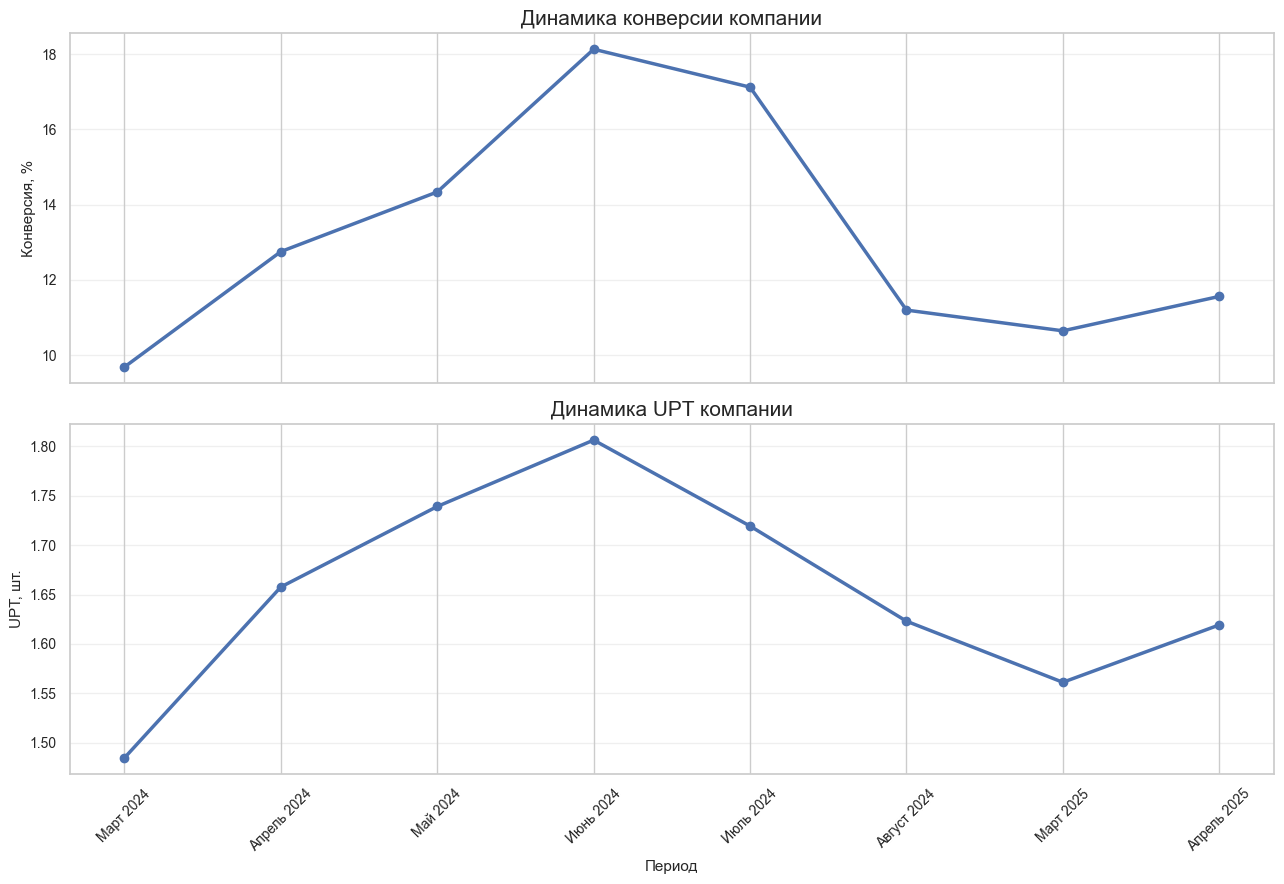

In [ ]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 9),
    sharex=True
)
# Conversion
axes[0].plot(
    company_monthly["Период"],
    company_monthly["Конверсия"] * 100,
    marker="o",
    linewidth=2.5
)
axes[0].set_title("Динамика конверсии компании")
axes[0].set_ylabel("Конверсия, %")
axes[0].grid(axis="y", alpha=0.3)
# UPT
axes[1].plot(
    company_monthly["Период"],
    company_monthly["UPT"],
    marker="o",
    linewidth=2.5
)
axes[1].set_title("Динамика UPT компании")

axes[1].set_ylabel("UPT, шт.")
axes[1].set_xlabel("Период")
axes[1].grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Распределение конверсии по категориям

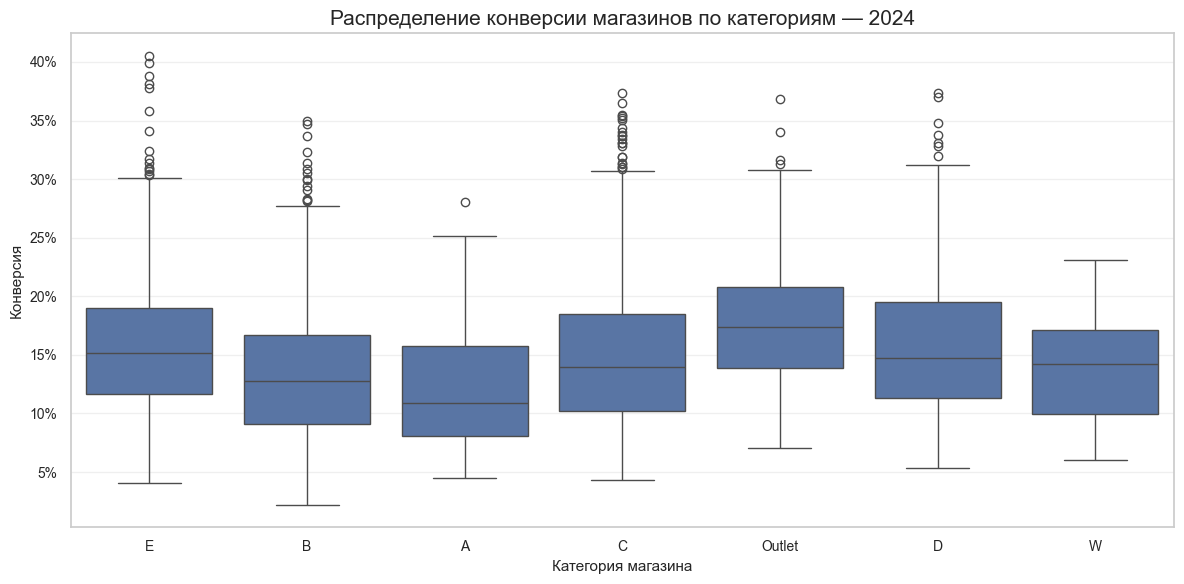

In [ ]:
plt.figure(figsize=(12, 6))

sb.boxplot(
    data=monthly[monthly["Год"] == 2024],
    x="Категория магазина",
    y="Конверсия"
)

plt.title("Распределение конверсии магазинов по категориям — 2024")

plt.xlabel("Категория магазина")
plt.ylabel("Конверсия")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.grid(axis = "y", alpha = 0.3)

plt.tight_layout()
plt.show()

# Распределение UPT по категориям

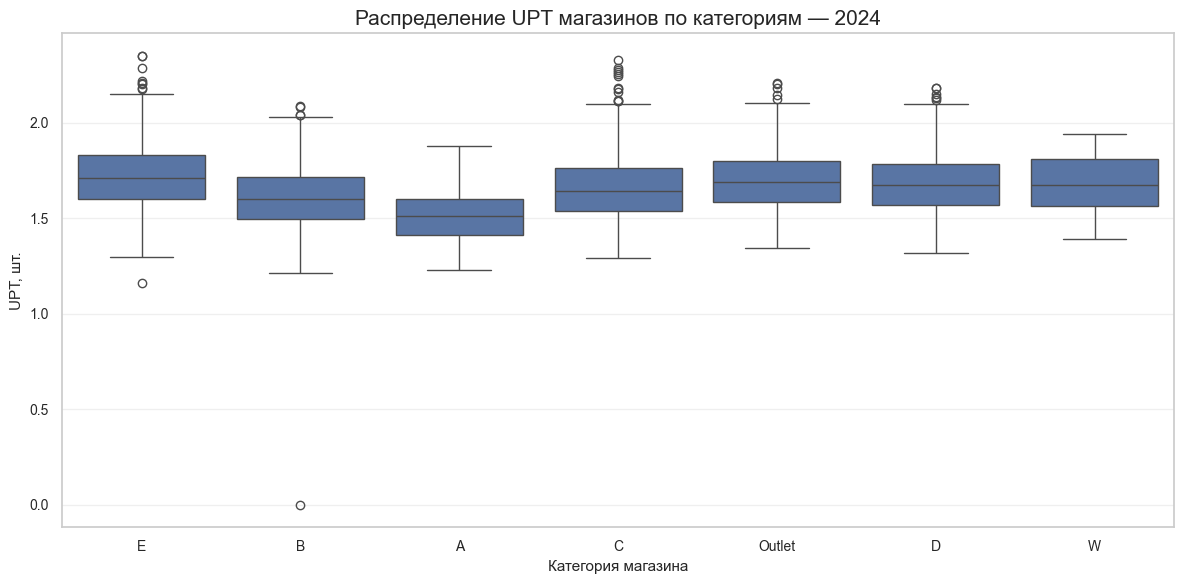

In [ ]:
plt.figure(figsize=(12, 6))

sb.boxplot(
    data=monthly[monthly["Год"] == 2024],
    x="Категория магазина",
    y="UPT"
)

plt.title("Распределение UPT магазинов по категориям — 2024")

plt.xlabel("Категория магазина")
plt.ylabel("UPT, шт.")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Конверсия по ФО и месяцам — Heatmap

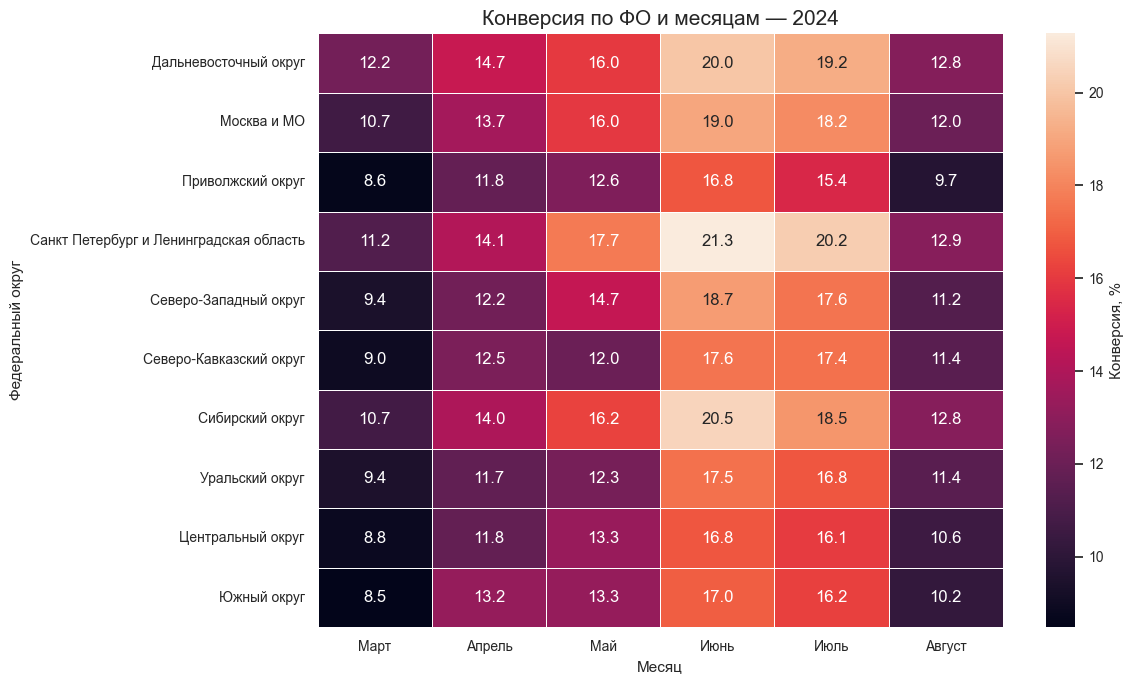

In [ ]:
heatmap_data = (
    fo_monthly
    .pivot(
        index="ФО",
        columns="Месяц",
        values="Конверсия"
    )
)

month_columns = [
    "Март",
    "Апрель",
    "Май",
    "Июнь",
    "Июль",
    "Август"
]

heatmap_data = heatmap_data[
    [m for m in month_columns if m in heatmap_data.columns]
]

plt.figure(figsize=(12, 7))
sb.heatmap(
    heatmap_data * 100,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={
        "label": "Конверсия, %"
    }
)
plt.title("Конверсия по ФО и месяцам — 2024")
plt.xlabel("Месяц")
plt.ylabel("Федеральный округ")

plt.tight_layout()
plt.show()

# Стабильность магазинов — по конверсии

In [60]:
stability

,Avg_Conversion_Index_2024,Avg_UPT_Index_2024,Avg_Conversion_Index_2025,Avg_UPT_Index_2025
ID магазина,,,,
2,0.985653,0.945338,0.926612,0.913958
3,1.128630,0.990164,1.145883,1.044033
4,0.939392,0.954071,0.806616,0.928742
29,1.187072,0.970441,1.061196,0.939225
35,0.921428,0.936035,0.804119,0.900441
...,...,...,...,...
3197,0.949232,1.206364,1.630751,1.189097
3199,0.417567,0.925737,0.437980,0.920857
3205,0.613004,0.985708,1.236963,1.015542


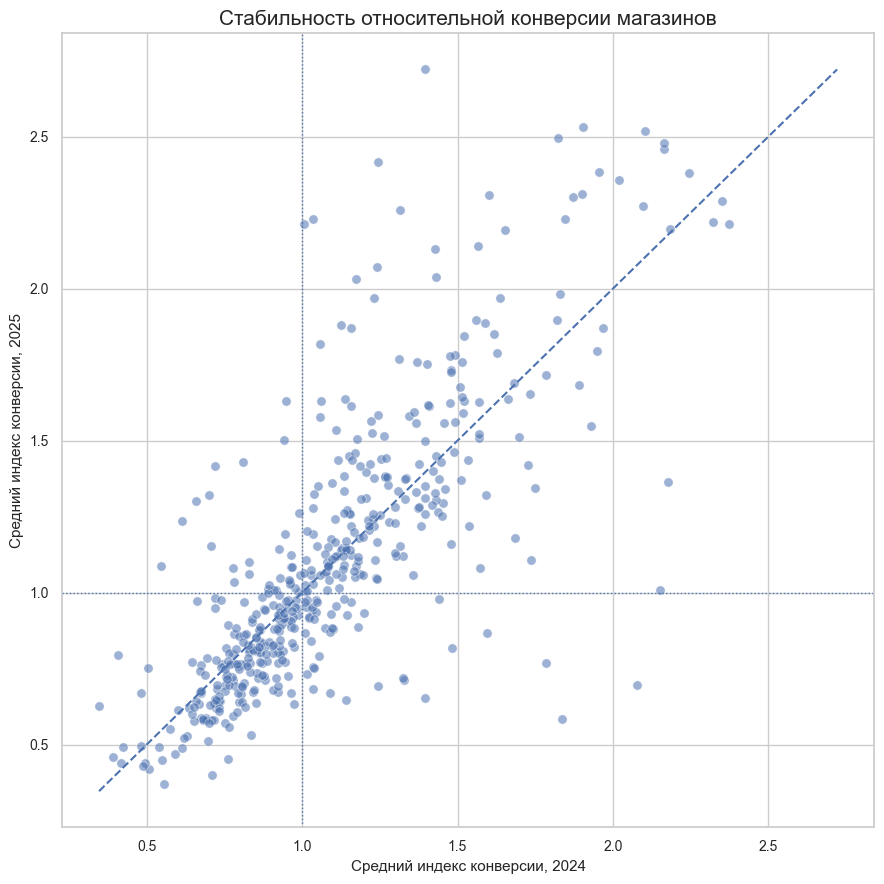

In [ ]:
plt.figure(figsize=(9, 9))
sb.scatterplot(
    data=stability,
    x="Avg_Conversion_Index_2024",
    y="Avg_Conversion_Index_2025",
    alpha=0.55,
    s=45
)

# Линия x = y
min_value = min(
    stability["Avg_Conversion_Index_2024"].min(),
    stability["Avg_Conversion_Index_2025"].min()
)

max_value = max(
    stability["Avg_Conversion_Index_2024"].max(),
    stability["Avg_Conversion_Index_2025"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.5
)
# Линии среднего уровня компании
plt.axhline(
    1,
    linestyle=":",
    linewidth=1
)
plt.axvline(
    1,
    linestyle=":",
    linewidth=1
)
plt.title("Стабильность относительной конверсии магазинов")
plt.xlabel("Средний индекс конверсии, 2024")
plt.ylabel("Средний индекс конверсии, 2025")

plt.tight_layout()
plt.show()

# Стабильность магазинов — по UPT

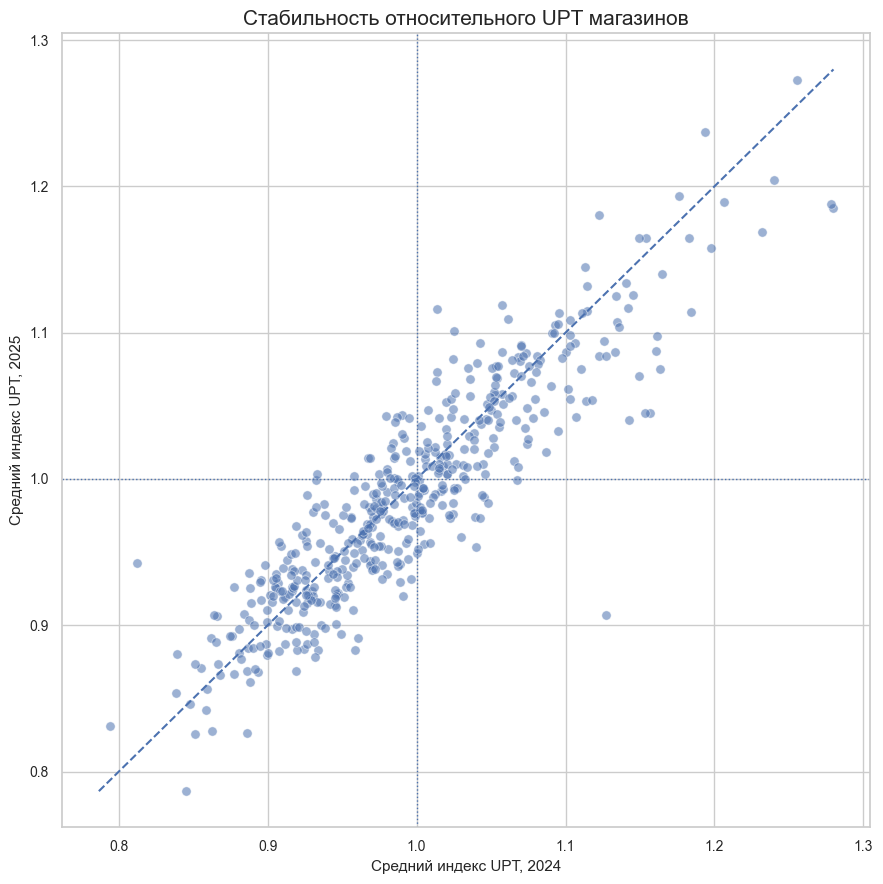

In [62]:
plt.figure(figsize=(9, 9))

sb.scatterplot(
    data=stability,
    x="Avg_UPT_Index_2024",
    y="Avg_UPT_Index_2025",
    alpha=0.55,
    s=45
)

min_value = min(
    stability["Avg_UPT_Index_2024"].min(),
    stability["Avg_UPT_Index_2025"].min()
)

max_value = max(
    stability["Avg_UPT_Index_2024"].max(),
    stability["Avg_UPT_Index_2025"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.5
)
plt.axhline(
    1,
    linestyle=":",
    linewidth=1
)
plt.axvline(
    1,
    linestyle=":",
    linewidth=1
)
plt.title("Стабильность относительного UPT магазинов")
plt.xlabel("Средний индекс UPT, 2024")
plt.ylabel("Средний индекс UPT, 2025")

plt.tight_layout()
plt.show()

In [122]:
df_goals

,index,"Конверсия, %","UPT, шт."
0,Март,0.113321,1.645528
1,Апрель,0.149218,1.688931
2,Май,0.167771,1.969249
3,Июнь,0.212170,1.712976
4,Июль,0.200368,1.672998
5,Август,0.131015,1.920391
6,Итого:,0.164576,1.762192


# План 2025 VS Факт 2024

In [131]:
fact_2024 = (
    company_monthly[
        company_monthly["Год"] == 2024
    ][
        [
            "Месяц",
            "Конверсия",
            "UPT"
        ]
    ]
    .rename(columns={
        "Конверсия": "Факт_Конверсия",
        "UPT": "Факт_UPT"
    })
)

goals_comparison = df_goals.merge(
    fact_2024,
    on="Месяц",
    how="left"
)

goals_comparison

,Месяц,"Конверсия, %","UPT, шт.",Факт_Конверсия,Факт_UPT
0,Март,0.113321,1.645528,0.096856,1.484560
1,Апрель,0.149218,1.688931,0.127536,1.657676
2,Май,0.167771,1.969249,0.143394,1.739223
3,Июнь,0.212170,1.712976,0.181342,1.806478
4,Июль,0.200368,1.672998,0.171255,1.719373
5,Август,0.131015,1.920391,0.111979,1.622999
6,Итого:,0.164576,1.762192,NaN,NaN


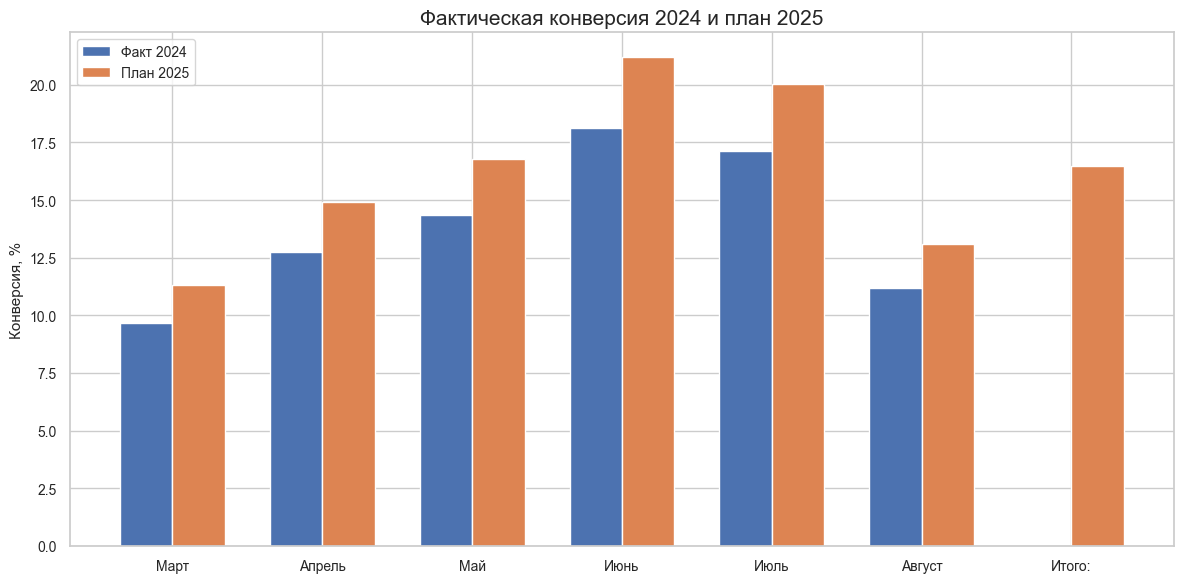

In [134]:
plt.figure(figsize=(12, 6))

x = np.arange(len(goals_comparison))

width = 0.35

plt.bar(
    x - width / 2,
    goals_comparison["Факт_Конверсия"] * 100,
    width,
    label="Факт 2024"
)

plt.bar(
    x + width / 2,
    goals_comparison["Конверсия, %"] * 100,
    width,
    label="План 2025"
)

plt.xticks(x, goals_comparison["Месяц"])
plt.ylabel("Конверсия, %")
plt.title("Фактическая конверсия 2024 и план 2025")
plt.legend()

plt.tight_layout()
plt.show()

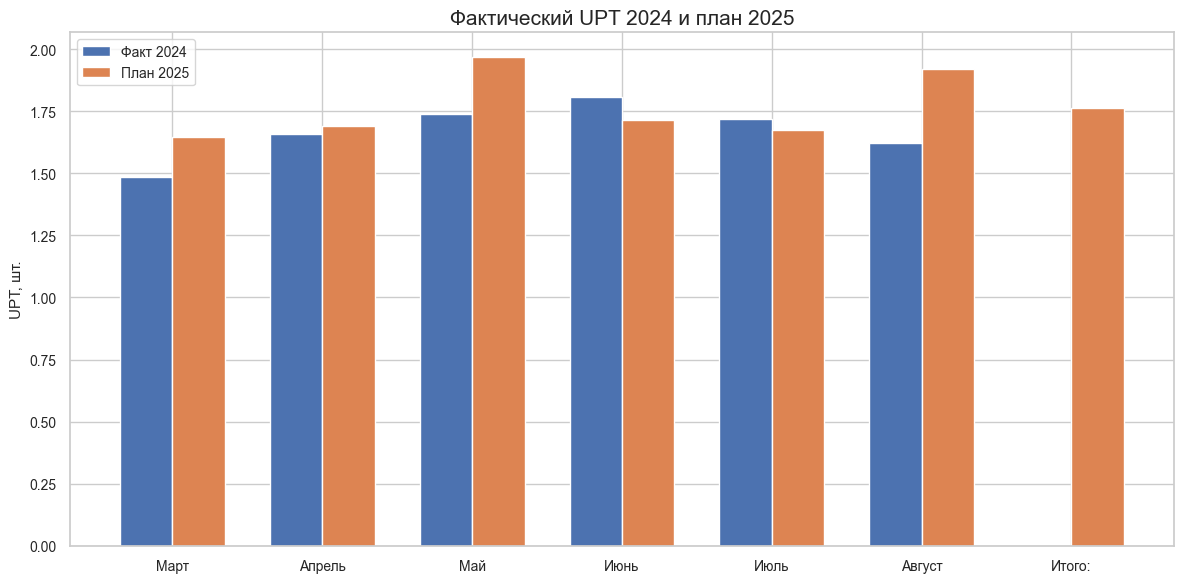

In [135]:
plt.figure(figsize=(12, 6))

x = np.arange(len(goals_comparison))

plt.bar(
    x - width / 2,
    goals_comparison["Факт_UPT"],
    width,
    label="Факт 2024"
)

plt.bar(
    x + width / 2,
    goals_comparison["UPT, шт."],
    width,
    label="План 2025"
)

plt.xticks(x, goals_comparison["Месяц"])
plt.ylabel("UPT, шт.")
plt.title("Фактический UPT 2024 и план 2025")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# df_raw.to_csv('Stores_Data.csv')